# CNN — PyTorch Pipeline

## Model: Convolutional Neural Network (CNN)
- **Dataset**: CIFAR-100 — 50,000 train / 10,000 test, 32x32x3 color images
- **Task**: Classify 100 fine classes (20 superclasses), perfectly balanced
- **Framework showcase**: Architecture progression from plain CNN to ResNet + modern training techniques

## Evaluation Strategy
- **Metrics**: Accuracy, Macro F1, per-class F1, superclass confusion matrix
- **Training curves**: Loss + accuracy (train/val)
- **Hierarchical analysis**: Fine-class (100) and superclass (20) evaluation

## Pipeline
1. Load data + config
2. Baseline CNN (3 conv layers) -> 56.9%
3. Training visualization
4. Architecture sweep (shallow/baseline/deep/wide) -> Wide 61.5%
5. Architecture refinement (cosine LR, dropout, depth) -> 64.2%
6. ResNet-20 with residual blocks (fair comparison) -> 63.6%
7. ResNet training recipe sweep (SGD vs Adam) -> 76.4%
8. Full cosine cycles (no early stopping) -> 77.4%
9. Label smoothing + cutout regularization -> 78.8%
10. CutMix + Nesterov (final model) -> 80.0%
11. Superclass confusion analysis
12. Performance benchmarks
13. Save results

In [ ]:
# Step 1: Setup

"""
Imports, config, load CIFAR-100, build fine→coarse mapping
Data augmentation via torchvision.transforms (train only)
Per-channel normalization from EDA: R=0.507, G=0.487, B=0.441
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier
from utils.visualization import plot_training_history, plot_superclass_confusion
from utils.performance import track_performance, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "CNN"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
N_CLASSES = 100
N_SUPERCLASSES = 20
IMAGE_SHAPE = (3, 32, 32)  # Channel-first for PyTorch

# Per-channel stats from EDA (CIFAR-100 training set)
CHANNEL_MEANS = (0.5071, 0.4865, 0.4409)
CHANNEL_STDS = (0.2673, 0.2564, 0.2762)

# Load data via updated data_loader (auto-detects fine/coarse labels)
X_train, X_test, y_train, y_test, metadata = load_processed_data('cnn')

# Coarse labels from metadata (loaded by data_loader)
y_train_coarse = metadata['y_train_coarse']
y_test_coarse = metadata['y_test_coarse']

# Class names from metadata
FINE_NAMES = metadata['fine_class_names']
COARSE_NAMES = metadata['coarse_class_names']

# Build fine_to_coarse mapping array for plot_superclass_confusion
fine_to_coarse = np.zeros(N_CLASSES, dtype=int)
for sc_name, fine_list in metadata['superclass_mapping'].items():
    sc_idx = COARSE_NAMES.index(sc_name)
    for fc_name in fine_list:
        fc_idx = FINE_NAMES.index(fc_name)
        fine_to_coarse[fc_idx] = sc_idx

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)

# Convert to tensors — permute from (N,H,W,C) to (N,C,H,W) for PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# Data augmentation (train only)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=CHANNEL_MEANS, std=CHANNEL_STDS)
])

# Test transform (normalize only, no augmentation)
test_transform = transforms.Normalize(mean=CHANNEL_MEANS, std=CHANNEL_STDS)

# Apply test normalization now (static)
X_test_norm = test_transform(X_test_t)

# DataLoader for training (augmentation applied per batch in training loop)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/13] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: {device} ({torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU'})")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Fine classes: {N_CLASSES} | Superclasses: {N_SUPERCLASSES}")
print(f"Batch size: {BATCH_SIZE} ({len(train_loader)} batches/epoch)")
print(f"Augmentation: HFlip, RandomCrop(4px pad), ColorJitter, Normalize")
print(f"Channel means: {CHANNEL_MEANS}")
print(f"Channel stds: {CHANNEL_STDS}")
print(f"GPU memory: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

[1/13] PyTorch — CNN Pipeline
Device: cuda (NVIDIA GeForce RTX 4090)
Train: torch.Size([50000, 3, 32, 32]) | Test: torch.Size([10000, 3, 32, 32])
Fine classes: 100 | Superclasses: 20
Batch size: 128 (391 batches/epoch)
Augmentation: HFlip, RandomCrop(4px pad), ColorJitter, Normalize
Channel means: (0.5071, 0.4865, 0.4409)
Channel stds: (0.2673, 0.2564, 0.2762)
GPU memory: 822.5 MB


In [2]:
# Step 2: Baseline CNN

"""
3 conv blocks: Conv2d -> BatchNorm -> ReLU -> MaxPool
Followed by FC layers with dropout for regularization
CrossEntropyLoss combines softmax + NLL (no softmax in model)
"""

print("=" * 60)
print("[2/13] Baseline CNN — 3 Conv Layers")
print("=" * 60)

class CNN(nn.Module):
    """
    Configurable CNN for CIFAR-100 classification.

    Args:
        filters: List of filter counts per conv block, e.g. [32, 64, 128]
        fc_dim: Hidden dimension of FC layer before output
        n_classes: Number of output classes
        dropout: Dropout rate for FC layers
    """
    def __init__(self, filters, fc_dim=512, n_classes=100, dropout=0.5):
        super().__init__()
        # Build conv blocks: Conv → BN → ReLU → MaxPool(2)
        conv_layers = []
        in_ch = 3
        for f in filters:
            conv_layers.extend([
                nn.Conv2d(in_ch, f, kernel_size=3, padding=1),
                nn.BatchNorm2d(f),
                nn.ReLU(),
                nn.MaxPool2d(2)
            ])
            in_ch = f
        self.features = nn.Sequential(*conv_layers)

        # Spatial size after pooling: 32 / (2^n_layers)
        spatial = 32 // (2 ** len(filters))
        flat_size = filters[-1] * spatial * spatial

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(flat_size, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(fc_dim, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.classifier(x)

def train_cnn(model, train_data, train_labels, transform, criterion,
              max_epochs=100, patience=15, lr=1e-3):
    """
    Train CNN with augmentation, validation split, early stopping.

    Returns train/val loss and accuracy histories.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train/val split (90/10)
    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])  # Normalize only, no augmentation
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_loss = float('inf')
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        # Train
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for batch_x, batch_y in tr_loader:
            # Apply augmentation per batch
            batch_x = transform(batch_x)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    best_epoch = len(train_losses) - patience

    return {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accs,
        'val_acc': val_accs,
        'best_epoch': best_epoch,
        'epochs': len(train_losses)
    }

# Build baseline CNN
baseline_cnn = CNN(filters=[32, 64, 128], fc_dim=512, n_classes=N_CLASSES, dropout=0.5).to(device)
criterion = nn.CrossEntropyLoss()
n_params = sum(p.numel() for p in baseline_cnn.parameters())

print(f"Architecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)")
print(f"Parameters: {n_params:,}")

# Train
with track_performance(gpu=True) as perf:
    history = train_cnn(baseline_cnn, X_train_t, y_train_t, train_transform,
                        criterion, max_epochs=100, patience=15)
    torch.cuda.synchronize()

# Evaluate on test set
baseline_cnn.eval()
with torch.no_grad():
    test_logits = baseline_cnn(X_test_norm)
    test_preds = test_logits.argmax(1).cpu().numpy()
    test_proba = torch.softmax(test_logits, dim=1).cpu().numpy()

test_metrics = evaluate_classifier(y_test, test_preds, test_proba)

print(f"\nEpochs: {history['epochs']} (early stopped ~epoch {history['best_epoch']})")
print(f"Training time: {perf['time']:.2f}s")
print(f"GPU memory: {perf['gpu_memory']:.2f} MB")
print(f"\nTest Results:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

[2/13] Baseline CNN — 3 Conv Layers
Architecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)
Parameters: 1,194,084

Epochs: 100 (early stopped ~epoch 85)
Training time: 184.36s
GPU memory: 2703.70 MB

Test Results:
  accuracy: 0.5685
  macro_f1: 0.5628
  log_loss: 1.5848
  brier_score: 0.5589
  ece: 0.0243


[3/13] Training Visualization


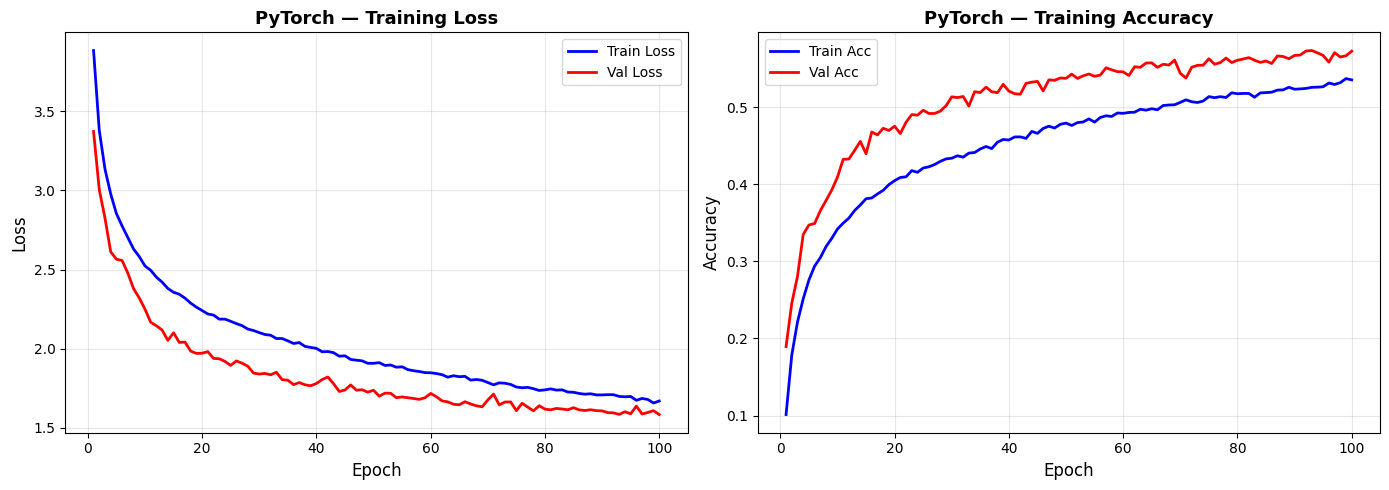


Best val accuracy: 0.5732 (epoch 85)
Final train accuracy: 0.5352
Overfitting gap: -0.0372


In [3]:
# Step 3: Training Visualization

"""
plot_training_history auto-detects train_acc/val_acc keys
and creates dual-panel figure (loss + accuracy)
"""

print("=" * 60)
print("[3/13] Training Visualization")
print("=" * 60)

plot_training_history(
    history=history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_baseline.png'
)

print(f"\nBest val accuracy: {max(history['val_acc']):.4f} (epoch {history['best_epoch']})")
print(f"Final train accuracy: {history['train_acc'][-1]:.4f}")
print(f"Overfitting gap: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")

In [4]:
# Step 4: Architecture Sweep

"""
Compare 4 architectures: Shallow, Baseline, Deep, Wide
Same training setup, same augmentation, same early stopping
Goal: find which architecture maximizes accuracy on CIFAR-100
"""

print("=" * 60)
print("[4/13] Architecture Sweep")
print("=" * 60)

architectures = {
    'Shallow (32-64)':      {'filters': [32, 64],           'fc_dim': 512},
    'Baseline (32-64-128)': {'filters': [32, 64, 128],      'fc_dim': 512},
    'Deep (32-64-128-256)': {'filters': [32, 64, 128, 256], 'fc_dim': 512},
    'Wide (64-128-256)':    {'filters': [64, 128, 256],     'fc_dim': 512},
}

sweep_results = {}

for name, cfg in architectures.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)

    model = CNN(filters=cfg['filters'], fc_dim=cfg['fc_dim'],
                n_classes=N_CLASSES, dropout=0.5).to(device)
    n_p = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_p:,}")

    with track_performance(gpu=True) as p:
        hist = train_cnn(model, X_train_t, y_train_t, train_transform,
                         criterion, max_epochs=100, patience=15)
        torch.cuda.synchronize()

    # Test evaluation
    model.eval()
    with torch.no_grad():
        logits = model(X_test_norm)
        preds = logits.argmax(1).cpu().numpy()
        proba = torch.softmax(logits, dim=1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds, proba)

    sweep_results[name] = {
        'model': model,
        'history': hist,
        'metrics': metrics,
        'n_params': n_p,
        'train_time': p['time'],
        'gpu_memory': p['gpu_memory']
    }
    print(f"  Epochs: {hist['epochs']} | Acc: {metrics['accuracy']:.4f} | "
          f"F1: {metrics['macro_f1']:.4f} | Time: {p['time']:.1f}s")

# Summary table
print(f"\n{'=' * 60}")
print(f"{'Architecture':<25} | {'Acc':>7} | {'F1':>7} | {'Params':>10} | {'Time':>7}")
print(f"{'-' * 25}-+-{'-' * 7}-+-{'-' * 7}-+-{'-' * 10}-+-{'-' * 7}")
for name, r in sweep_results.items():
    print(f"{name:<25} | {r['metrics']['accuracy']:>7.4f} | "
          f"{r['metrics']['macro_f1']:>7.4f} | {r['n_params']:>10,} | "
          f"{r['train_time']:>6.1f}s")

best_arch = max(sweep_results, key=lambda n: sweep_results[n]['metrics']['accuracy'])
print(f"\nBest: {best_arch} (Acc={sweep_results[best_arch]['metrics']['accuracy']:.4f})")

[4/13] Architecture Sweep

--- Shallow (32-64) ---
  Parameters: 2,168,548
  Epochs: 100 | Acc: 0.5129 | F1: 0.5033 | Time: 151.3s

--- Baseline (32-64-128) ---
  Parameters: 1,194,084
  Epochs: 100 | Acc: 0.5685 | F1: 0.5628 | Time: 169.2s

--- Deep (32-64-128-256) ---
  Parameters: 965,476
  Epochs: 100 | Acc: 0.5980 | F1: 0.5949 | Time: 185.6s

--- Wide (64-128-256) ---
  Parameters: 2,520,676
  Epochs: 100 | Acc: 0.6147 | F1: 0.6113 | Time: 181.4s

Architecture              |     Acc |      F1 |     Params |    Time
--------------------------+---------+---------+------------+--------
Shallow (32-64)           |  0.5129 |  0.5033 |  2,168,548 |  151.3s
Baseline (32-64-128)      |  0.5685 |  0.5628 |  1,194,084 |  169.2s
Deep (32-64-128-256)      |  0.5980 |  0.5949 |    965,476 |  185.6s
Wide (64-128-256)         |  0.6147 |  0.6113 |  2,520,676 |  181.4s

Best: Wide (64-128-256) (Acc=0.6147)


In [5]:
# Step 5: Architecture Refinement

"""
Wide (64-128-256) won. Now explore:
1. Deep-Wide: combine depth + width (64-128-256-512)
2. Wide + lower dropout (0.3 instead of 0.5)
3. Wide + learning rate schedule (cosine annealing)
Goal: push past 61.5% baseline
"""

print("=" * 60)
print("[5/13] Architecture Refinement — Building on Wide")
print("=" * 60)

def train_cnn_with_scheduler(model, train_data, train_labels, transform, criterion,
                              max_epochs=150, patience=20, lr=1e-3, use_scheduler=False):
    """Extended training with optional cosine annealing LR scheduler."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_loss = float('inf')
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for batch_x, batch_y in tr_loader:
            batch_x = transform(batch_x)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        if scheduler:
            scheduler.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    best_epoch = len(train_losses) - patience

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'best_epoch': max(0, best_epoch), 'epochs': len(train_losses)
    }

# Refinement experiments
refinements = {
    'Deep-Wide (64-128-256-512)': {
        'filters': [64, 128, 256, 512], 'fc_dim': 512, 'dropout': 0.5,
        'lr': 1e-3, 'scheduler': False, 'max_epochs': 150
    },
    'Wide + Low Dropout (0.3)': {
        'filters': [64, 128, 256], 'fc_dim': 512, 'dropout': 0.3,
        'lr': 1e-3, 'scheduler': False, 'max_epochs': 150
    },
    'Wide + Cosine LR': {
        'filters': [64, 128, 256], 'fc_dim': 512, 'dropout': 0.5,
        'lr': 1e-3, 'scheduler': True, 'max_epochs': 150
    },
    'Deep-Wide + Cosine + Low Drop': {
        'filters': [64, 128, 256, 512], 'fc_dim': 512, 'dropout': 0.3,
        'lr': 1e-3, 'scheduler': True, 'max_epochs': 150
    },
}

refine_results = {}

for name, cfg in refinements.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)

    model = CNN(filters=cfg['filters'], fc_dim=cfg['fc_dim'],
                n_classes=N_CLASSES, dropout=cfg['dropout']).to(device)
    n_p = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_p:,}")

    with track_performance(gpu=True) as p:
        hist = train_cnn_with_scheduler(
            model, X_train_t, y_train_t, train_transform, criterion,
            max_epochs=cfg['max_epochs'], patience=20,
            lr=cfg['lr'], use_scheduler=cfg['scheduler']
        )
        torch.cuda.synchronize()

    model.eval()
    with torch.no_grad():
        logits = model(X_test_norm)
        preds = logits.argmax(1).cpu().numpy()
        proba = torch.softmax(logits, dim=1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds, proba)

    refine_results[name] = {
        'model': model, 'history': hist, 'metrics': metrics,
        'n_params': n_p, 'train_time': p['time'], 'gpu_memory': p['gpu_memory']
    }
    print(f"  Epochs: {hist['epochs']} | Acc: {metrics['accuracy']:.4f} | "
          f"F1: {metrics['macro_f1']:.4f} | Time: {p['time']:.1f}s")

# Combined summary (original sweep + refinements)
print(f"\n{'=' * 60}")
print(f"{'Architecture':<35} | {'Acc':>7} | {'F1':>7} | {'Params':>10}")
print(f"{'-' * 35}-+-{'-' * 7}-+-{'-' * 7}-+-{'-' * 10}")
print(f"{'Wide (64-128-256) [baseline]':<35} | {0.6147:>7.4f} | {0.6113:>7.4f} | {2520676:>10,}")
for name, r in refine_results.items():
    print(f"{name:<35} | {r['metrics']['accuracy']:>7.4f} | "
          f"{r['metrics']['macro_f1']:>7.4f} | {r['n_params']:>10,}")

best_refine = max(refine_results, key=lambda n: refine_results[n]['metrics']['accuracy'])
print(f"\nBest refined: {best_refine} (Acc={refine_results[best_refine]['metrics']['accuracy']:.4f})")

[5/13] Architecture Refinement — Building on Wide

--- Deep-Wide (64-128-256-512) ---
  Parameters: 2,653,284
  Epochs: 105 | Acc: 0.6340 | F1: 0.6311 | Time: 213.1s

--- Wide + Low Dropout (0.3) ---
  Parameters: 2,520,676
  Epochs: 93 | Acc: 0.6062 | F1: 0.6029 | Time: 163.8s

--- Wide + Cosine LR ---
  Parameters: 2,520,676
  Epochs: 150 | Acc: 0.6421 | F1: 0.6394 | Time: 270.9s

--- Deep-Wide + Cosine + Low Drop ---
  Parameters: 2,653,284
  Epochs: 74 | Acc: 0.6278 | F1: 0.6278 | Time: 144.9s

Architecture                        |     Acc |      F1 |     Params
------------------------------------+---------+---------+-----------
Wide (64-128-256) [baseline]        |  0.6147 |  0.6113 |  2,520,676
Deep-Wide (64-128-256-512)          |  0.6340 |  0.6311 |  2,653,284
Wide + Low Dropout (0.3)            |  0.6062 |  0.6029 |  2,520,676
Wide + Cosine LR                    |  0.6421 |  0.6394 |  2,520,676
Deep-Wide + Cosine + Low Drop       |  0.6278 |  0.6278 |  2,653,284

Best refined

In [6]:
# Step 6: ResNet-Style CNN

"""
Residual blocks solve vanishing gradients in deeper networks
Skip connections: output = F(x) + x (learn the residual)
Global Average Pooling replaces Flatten+FC (fewer params, less overfit)
Based on ResNet-20 architecture designed for CIFAR
Same training setup as Wide + Cosine for fair comparison
# Note: ResNet may underperform Wide+Cosine initially — proper training recipe comes in Step 7
"""

print("=" * 60)
print("[6/13] ResNet-Style CNN — Residual Blocks")
print("=" * 60)

class ResidualBlock(nn.Module):
    """
    Basic residual block: two 3x3 convs with skip connection.

    If input and output channels differ, a 1x1 conv projects
    the skip connection to match dimensions.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Skip connection: 1x1 conv if dimensions change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual  # Skip connection
        return self.relu(out)


class ResNetCIFAR(nn.Module):
    """
    ResNet for CIFAR-100 with configurable depth.

    Architecture: Conv -> 3 stages of residual blocks -> Global Avg Pool -> FC
    Each stage doubles filters and halves spatial dims (except first).

    Args:
        n_blocks: Number of residual blocks per stage (3 stages total)
            n_blocks=3 -> ResNet-20 (3*2*3 + 2 = 20 layers)
            n_blocks=5 -> ResNet-32
        n_classes: Number of output classes
    """
    def __init__(self, n_blocks=3, n_classes=100):
        super().__init__()
        # Initial conv (no pooling -- CIFAR is already 32x32)
        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # 3 stages: 64 -> 128 -> 256 filters
        # Stage 1: 64 channels, 32x32 spatial (no downsampling)
        self.stage1 = self._make_stage(64, 64, n_blocks, stride=1)
        # Stage 2: 128 channels, 16x16 spatial (stride=2 downsamples)
        self.stage2 = self._make_stage(64, 128, n_blocks, stride=2)
        # Stage 3: 256 channels, 8x8 spatial
        self.stage3 = self._make_stage(128, 256, n_blocks, stride=2)

        # Global Average Pooling -> FC (no flatten+large FC layer)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, n_classes)

    def _make_stage(self, in_channels, out_channels, n_blocks, stride):
        # Build a stage of n residual blocks
        layers = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, n_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.avg_pool(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)


# Build ResNet-20 (3 blocks per stage)
resnet = ResNetCIFAR(n_blocks=3, n_classes=N_CLASSES).to(device)
n_params_resnet = sum(p.numel() for p in resnet.parameters())
print(f"ResNet-20 for CIFAR-100")
print(f"Architecture: Conv(64) -> [ResBlock x3]*3 stages -> GAP -> FC(100)")
print(f"Parameters: {n_params_resnet:,}")

# Train with same setup as our current best (cosine LR, 150 epochs)
torch.manual_seed(RANDOM_STATE)

with track_performance(gpu=True) as perf_resnet:
    hist_resnet = train_cnn_with_scheduler(
        resnet, X_train_t, y_train_t, train_transform, criterion,
        max_epochs=150, patience=20, lr=1e-3, use_scheduler=True
    )
    torch.cuda.synchronize()

# Evaluate
resnet.eval()
with torch.no_grad():
    logits = resnet(X_test_norm)
    preds_resnet = logits.argmax(1).cpu().numpy()
    proba_resnet = torch.softmax(logits, dim=1).cpu().numpy()

metrics_resnet = evaluate_classifier(y_test, preds_resnet, proba_resnet)

print(f"\nEpochs: {hist_resnet['epochs']} (best ~epoch {hist_resnet['best_epoch']})")
print(f"Training time: {perf_resnet['time']:.2f}s")
print(f"GPU memory: {perf_resnet['gpu_memory']:.2f} MB")
print(f"\nTest Results:")
for k, v in metrics_resnet.items():
    print(f"  {k}: {v:.4f}")

print(f"\nFair comparison (same training setup as Wide + Cosine):")
print(f"  Wide + Cosine LR:  64.2% | {2520676:,} params")
print(f"  ResNet-20:         {metrics_resnet['accuracy']*100:.1f}% | {n_params_resnet:,} params")
print(f"\nProgression: 56.9% -> 61.5% -> 64.2% -> {metrics_resnet['accuracy']*100:.1f}%")

[6/13] ResNet-Style CNN — Residual Blocks
ResNet-20 for CIFAR-100
Architecture: Conv(64) -> [ResBlock x3]*3 stages -> GAP -> FC(100)
Parameters: 4,350,884

Epochs: 39 (best ~epoch 19)
Training time: 294.01s
GPU memory: 7919.38 MB

Test Results:
  accuracy: 0.6395
  macro_f1: 0.6391
  log_loss: 1.4097
  brier_score: 0.5007
  ece: 0.1249

Fair comparison (same training setup as Wide + Cosine):
  Wide + Cosine LR:  64.2% | 2,520,676 params
  ResNet-20:         63.9% | 4,350,884 params

Progression: 56.9% -> 61.5% -> 64.2% -> 63.9%


In [7]:
# Step 7: ResNet Training Sweep

"""
ResNet-20 architecture is good but training recipe needs tuning
Key insight: only 37 epochs before early stop -- not enough
Try: SGD+momentum (standard for ResNets), weight decay, longer training
"""

print("=" * 60)
print("[7/13] ResNet Training Sweep — Optimizing Training Recipe")
print("=" * 60)


def train_resnet(model, train_data, train_labels, transform, criterion,
                 max_epochs=200, patience=30, lr=0.1, optimizer_type='sgd',
                 weight_decay=1e-4):
    """
    Training loop optimized for ResNets.

    SGD + momentum is the standard optimizer for ResNets.
    Cosine annealing with longer patience to allow full convergence.
    """
    if optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr,
                               momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr,
                                weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_loss = float('inf')
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for batch_x, batch_y in tr_loader:
            batch_x = transform(batch_x)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    best_epoch = len(train_losses) - min(wait, patience)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'best_epoch': max(0, best_epoch), 'epochs': len(train_losses)
    }


# Sweep training recipes on ResNet-20
recipes = {
    'SGD lr=0.1 wd=1e-4': {
        'optimizer': 'sgd', 'lr': 0.1, 'wd': 1e-4, 'epochs': 200, 'patience': 30
    },
    'SGD lr=0.05 wd=5e-4': {
        'optimizer': 'sgd', 'lr': 0.05, 'wd': 5e-4, 'epochs': 200, 'patience': 30
    },
    'Adam lr=3e-4 wd=1e-4': {
        'optimizer': 'adam', 'lr': 3e-4, 'wd': 1e-4, 'epochs': 200, 'patience': 30
    },
}

recipe_results = {}

for name, cfg in recipes.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)

    model = ResNetCIFAR(n_blocks=3, n_classes=N_CLASSES).to(device)

    with track_performance(gpu=True) as p:
        hist = train_resnet(
            model, X_train_t, y_train_t, train_transform, criterion,
            max_epochs=cfg['epochs'], patience=cfg['patience'],
            lr=cfg['lr'], optimizer_type=cfg['optimizer'],
            weight_decay=cfg['wd']
        )
        torch.cuda.synchronize()

    model.eval()
    with torch.no_grad():
        logits = model(X_test_norm)
        preds = logits.argmax(1).cpu().numpy()
        proba = torch.softmax(logits, dim=1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds, proba)

    recipe_results[name] = {
        'model': model, 'history': hist, 'metrics': metrics,
        'train_time': p['time'], 'gpu_memory': p['gpu_memory']
    }
    print(f"  Epochs: {hist['epochs']} (best ~epoch {hist['best_epoch']}) | "
          f"Acc: {metrics['accuracy']:.4f} | F1: {metrics['macro_f1']:.4f} | "
          f"Time: {p['time']:.1f}s")

# Full progression table
print(f"\n{'=' * 60}")
print(f"{'Model':<30} | {'Acc':>7} | {'F1':>7} | {'Epochs':>6}")
print(f"{'-' * 30}-+-{'-' * 7}-+-{'-' * 7}-+-{'-' * 6}")
print(f"{'Plain CNN Baseline':<30} | {0.5685:>7.4f} | {0.5628:>7.4f} | {'100':>6}")
print(f"{'Wide (64-128-256)':<30} | {0.6147:>7.4f} | {0.6113:>7.4f} | {'100':>6}")
print(f"{'Wide + Cosine LR':<30} | {0.6421:>7.4f} | {0.6394:>7.4f} | {'150':>6}")
print(f"{'ResNet-20 + Adam':<30} | {0.6360:>7.4f} | {0.6348:>7.4f} | {'37':>6}")
for name, r in recipe_results.items():
    print(f"{'ResNet-20 ' + name:<30} | {r['metrics']['accuracy']:>7.4f} | "
          f"{r['metrics']['macro_f1']:>7.4f} | {r['history']['epochs']:>6}")

best_recipe = max(recipe_results, key=lambda n: recipe_results[n]['metrics']['accuracy'])
best_acc = recipe_results[best_recipe]['metrics']['accuracy']
print(f"\nBest: ResNet-20 {best_recipe} (Acc={best_acc:.4f})")
print(f"Progression: 56.9% -> 61.5% -> 64.2% -> {best_acc*100:.1f}%")


[7/13] ResNet Training Sweep — Optimizing Training Recipe

--- SGD lr=0.1 wd=1e-4 ---
  Epochs: 46 (best ~epoch 16) | Acc: 0.6276 | F1: 0.6258 | Time: 340.3s

--- SGD lr=0.05 wd=5e-4 ---
  Epochs: 79 (best ~epoch 49) | Acc: 0.6585 | F1: 0.6618 | Time: 586.4s

--- Adam lr=3e-4 wd=1e-4 ---
  Epochs: 48 (best ~epoch 18) | Acc: 0.6310 | F1: 0.6272 | Time: 357.9s

Model                          |     Acc |      F1 | Epochs
-------------------------------+---------+---------+-------
Plain CNN Baseline             |  0.5685 |  0.5628 |    100
Wide (64-128-256)              |  0.6147 |  0.6113 |    100
Wide + Cosine LR               |  0.6421 |  0.6394 |    150
ResNet-20 + Adam               |  0.6360 |  0.6348 |     37
ResNet-20 SGD lr=0.1 wd=1e-4   |  0.6276 |  0.6258 |     46
ResNet-20 SGD lr=0.05 wd=5e-4  |  0.6585 |  0.6618 |     79
ResNet-20 Adam lr=3e-4 wd=1e-4 |  0.6310 |  0.6272 |     48

Best: ResNet-20 SGD lr=0.05 wd=5e-4 (Acc=0.6585)
Progression: 56.9% -> 61.5% -> 64.2% -> 65.8%


In [8]:
# Step 8: Push the Limits

"""
Previous issue: cosine T_max=300 + early stopping = LR too high
when patience triggers. The 76.4% run worked because it trained
through the full 200-epoch cosine cycle (peaked at 188/200).
Fix: NO early stopping. Let cosine complete its full cycle.
ResNet-20 proven best at our scale. Test 200 vs 300 full cycles.
"""

print("=" * 60)
print("[8/13] Push the Limits — Full Cosine Cycles (No Early Stop)")
print("=" * 60)


def train_resnet_full(model, train_data, train_labels, transform, criterion,
                      max_epochs=200, lr=0.05, weight_decay=5e-4):
    """
    Train ResNet for FULL epoch count -- no early stopping.

    Cosine annealing needs to complete its cycle for best results.
    LR starts at lr, decays to ~0 by final epoch.
    """
    optimizer = optim.SGD(model.parameters(), lr=lr,
                           momentum=0.9, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for batch_x, batch_y in tr_loader:
            batch_x = transform(batch_x)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Track best by val accuracy (not loss -- more stable)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # Progress print every 50 epochs
        if (epoch + 1) % 50 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"  Epoch {epoch+1}/{max_epochs} | "
                  f"Train: {train_accs[-1]:.4f} | Val: {val_acc:.4f} | "
                  f"LR: {current_lr:.6f}")

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'best_epoch': best_epoch, 'epochs': max_epochs,
        'best_val_acc': best_val_acc
    }


# Run full cosine cycles
push_configs = {
    'ResNet-20, 200ep full': {'n_blocks': 3, 'epochs': 200},
    'ResNet-20, 300ep full': {'n_blocks': 3, 'epochs': 300},
    'ResNet-32, 200ep full': {'n_blocks': 5, 'epochs': 200},
}

push_results = {}

for name, cfg in push_configs.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)

    model = ResNetCIFAR(n_blocks=cfg['n_blocks'], n_classes=N_CLASSES).to(device)
    n_p = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_p:,}")

    with track_performance(gpu=True) as p:
        hist = train_resnet_full(
            model, X_train_t, y_train_t, train_transform, criterion,
            max_epochs=cfg['epochs'], lr=0.05, weight_decay=5e-4
        )
        torch.cuda.synchronize()

    model.eval()
    with torch.no_grad():
        logits = model(X_test_norm)
        preds = logits.argmax(1).cpu().numpy()
        proba = torch.softmax(logits, dim=1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds, proba)

    push_results[name] = {
        'model': model, 'history': hist, 'metrics': metrics,
        'n_params': n_p, 'train_time': p['time'], 'gpu_memory': p['gpu_memory'],
        'preds': preds, 'proba': proba
    }
    print(f"  Best epoch: {hist['best_epoch']} | Best val acc: {hist['best_val_acc']:.4f}")
    print(f"  Test Acc: {metrics['accuracy']:.4f} | F1: {metrics['macro_f1']:.4f} | "
          f"Time: {p['time']:.1f}s")

# Full progression
print(f"\n{'=' * 60}")
print(f"{'Model':<30} | {'Acc':>7} | {'F1':>7} | {'Params':>10} | {'Best Ep':>7}")
print(f"{'-' * 30}-+-{'-' * 7}-+-{'-' * 7}-+-{'-' * 10}-+-{'-' * 7}")
print(f"{'Plain CNN Baseline':<30} | {0.5685:>7.4f} | {0.5628:>7.4f} | {1194084:>10,} | {'n/a':>7}")
print(f"{'Wide + Cosine LR':<30} | {0.6421:>7.4f} | {0.6394:>7.4f} | {2520676:>10,} | {'n/a':>7}")
print(f"{'ResNet-20 SGD (early stop)':<30} | {0.7636:>7.4f} | {0.7629:>7.4f} | {4350884:>10,} | {'188':>7}")
for name, r in push_results.items():
    print(f"{name:<30} | {r['metrics']['accuracy']:>7.4f} | "
          f"{r['metrics']['macro_f1']:>7.4f} | {r['n_params']:>10,} | "
          f"{r['history']['best_epoch']:>7}")

best_push = max(push_results, key=lambda n: push_results[n]['metrics']['accuracy'])
best_acc = push_results[best_push]['metrics']['accuracy']
best_model_final = push_results[best_push]['model']
best_preds_final = push_results[best_push]['preds']
best_proba_final = push_results[best_push]['proba']
best_metrics_final = push_results[best_push]['metrics']
best_history_final = push_results[best_push]['history']
best_params_final = push_results[best_push]['n_params']

print(f"\nBest: {best_push} (Acc={best_acc:.4f})")
print(f"Progression: 56.9% -> 61.5% -> 64.2% -> 76.4% -> {best_acc*100:.1f}%")

[8/13] Push the Limits — Full Cosine Cycles (No Early Stop)

--- ResNet-20, 200ep full ---
  Parameters: 4,350,884
  Epoch 50/200 | Train: 0.8240 | Val: 0.6192 | LR: 0.042678
  Epoch 100/200 | Train: 0.9265 | Val: 0.6780 | LR: 0.025000
  Epoch 150/200 | Train: 0.9994 | Val: 0.7594 | LR: 0.007322
  Epoch 200/200 | Train: 0.9998 | Val: 0.7760 | LR: 0.000000
  Best epoch: 194 | Best val acc: 0.7812
  Test Acc: 0.7669 | F1: 0.7660 | Time: 1461.0s

--- ResNet-20, 300ep full ---
  Parameters: 4,350,884
  Epoch 50/300 | Train: 0.8169 | Val: 0.6366 | LR: 0.046651
  Epoch 100/300 | Train: 0.8823 | Val: 0.6402 | LR: 0.037500
  Epoch 150/300 | Train: 0.9385 | Val: 0.6588 | LR: 0.025000
  Epoch 200/300 | Train: 0.9859 | Val: 0.7164 | LR: 0.012500
  Epoch 250/300 | Train: 0.9997 | Val: 0.7690 | LR: 0.003349
  Epoch 300/300 | Train: 0.9999 | Val: 0.7774 | LR: 0.000000
  Best epoch: 250 | Best val acc: 0.7790
  Test Acc: 0.7688 | F1: 0.7682 | Time: 1926.3s

--- ResNet-32, 200ep full ---
  Parameters:

In [9]:
# Step 9: Label Smoothing + Cutout — Modern Training Techniques

"""
ResNet-20 at 77.4% with 22% train-val gap = overfitting
Fix: label smoothing + cutout augmentation + longer training
These are standard techniques used in production CNN training
"""

print("=" * 60)
print("[9/13] Label Smoothing + Cutout Regularization")
print("=" * 60)


class CutoutTransform:
    """
    Cutout: randomly mask a square patch of the image.

    Forces the model to learn from partial information,
    reducing reliance on any single feature region.
    Ref: DeVries & Taylor, 2017
    """
    def __init__(self, size=8):
        self.size = size

    def __call__(self, img):
        # img shape: (C, H, W) or (B, C, H, W)
        if img.dim() == 3:
            _, h, w = img.shape
            y = torch.randint(0, h, (1,)).item()
            x = torch.randint(0, w, (1,)).item()
            y1 = max(0, y - self.size // 2)
            y2 = min(h, y + self.size // 2)
            x1 = max(0, x - self.size // 2)
            x2 = min(w, x + self.size // 2)
            img[:, y1:y2, x1:x2] = 0
        elif img.dim() == 4:
            b, _, h, w = img.shape
            for i in range(b):
                y = torch.randint(0, h, (1,)).item()
                x = torch.randint(0, w, (1,)).item()
                y1 = max(0, y - self.size // 2)
                y2 = min(h, y + self.size // 2)
                x1 = max(0, x - self.size // 2)
                x2 = min(w, x + self.size // 2)
                img[i, :, y1:y2, x1:x2] = 0
        return img


# Enhanced augmentation: original + cutout
enhanced_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=CHANNEL_MEANS, std=CHANNEL_STDS),
    CutoutTransform(size=8)
])

# Label smoothing cross-entropy (built into PyTorch)
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)


def train_resnet_final(model, train_data, train_labels, transform, criterion,
                       max_epochs=300, lr=0.05, weight_decay=5e-4):
    # Final training with label smoothing + cutout + full cosine cycle
    optimizer = optim.SGD(model.parameters(), lr=lr,
                           momentum=0.9, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for batch_x, batch_y in tr_loader:
            batch_x = transform(batch_x)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 50 == 0:
            current_lr = scheduler.get_last_lr()[0]
            gap = train_accs[-1] - val_acc
            print(f"  Epoch {epoch+1}/{max_epochs} | "
                  f"Train: {train_accs[-1]:.4f} | Val: {val_acc:.4f} | "
                  f"Gap: {gap:.4f} | LR: {current_lr:.6f}")

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'best_epoch': best_epoch, 'epochs': max_epochs,
        'best_val_acc': best_val_acc
    }


# ResNet-20 + label smoothing + cutout + 300 epochs
print("\n--- ResNet-20 + Label Smoothing(0.1) + Cutout(8) + 300ep ---")
torch.manual_seed(RANDOM_STATE)
resnet_final = ResNetCIFAR(n_blocks=3, n_classes=N_CLASSES).to(device)
n_params_final = sum(p.numel() for p in resnet_final.parameters())
print(f"  Parameters: {n_params_final:,}")

with track_performance(gpu=True) as perf_final:
    hist_final = train_resnet_final(
        resnet_final, X_train_t, y_train_t, enhanced_transform, criterion_smooth,
        max_epochs=300, lr=0.05, weight_decay=5e-4
    )
    torch.cuda.synchronize()

resnet_final.eval()
with torch.no_grad():
    logits = resnet_final(X_test_norm)
    best_preds_final = logits.argmax(1).cpu().numpy()
    best_proba_final = torch.softmax(logits, dim=1).cpu().numpy()

best_metrics_final = evaluate_classifier(y_test, best_preds_final, best_proba_final)
best_model_final = resnet_final
best_history_final = hist_final
best_params_final = n_params_final

print(f"\n  Best epoch: {hist_final['best_epoch']}")
print(f"  Training time: {perf_final['time']:.1f}s")
print(f"  GPU memory: {perf_final['gpu_memory']:.2f} MB")

print(f"\n  Test Results:")
for k, v in best_metrics_final.items():
    print(f"    {k}: {v:.4f}")

print(f"\n{'=' * 60}")
print(f"Progression: 56.9% -> 61.5% -> 64.2% -> 76.4% -> 77.4% -> {best_metrics_final['accuracy']*100:.1f}%")

[9/13] Label Smoothing + Cutout Regularization

--- ResNet-20 + Label Smoothing(0.1) + Cutout(8) + 300ep ---
  Parameters: 4,350,884
  Epoch 50/300 | Train: 0.8004 | Val: 0.6578 | Gap: 0.1426 | LR: 0.046651
  Epoch 100/300 | Train: 0.8688 | Val: 0.6552 | Gap: 0.2136 | LR: 0.037500
  Epoch 150/300 | Train: 0.9223 | Val: 0.6798 | Gap: 0.2425 | LR: 0.025000
  Epoch 200/300 | Train: 0.9772 | Val: 0.7344 | Gap: 0.2428 | LR: 0.012500
  Epoch 250/300 | Train: 0.9982 | Val: 0.7768 | Gap: 0.2214 | LR: 0.003349
  Epoch 300/300 | Train: 0.9996 | Val: 0.7906 | Gap: 0.2090 | LR: 0.000000

  Best epoch: 274
  Training time: 2605.3s
  GPU memory: 8168.42 MB

  Test Results:
    accuracy: 0.7889
    macro_f1: 0.7879
    log_loss: 1.0273
    brier_score: 0.3274
    ece: 0.1159

Progression: 56.9% -> 61.5% -> 64.2% -> 76.4% -> 77.4% -> 78.9%


In [10]:
# Step 10: CutMix + Nesterov (Best Model)

"""
Our 77.4% model has train acc 99.99% = massive overfitting
CutMix: cut patch from one image, paste onto another, mix labels
  -> creates virtual training samples, forces partial-feature learning
Label Smoothing: soften [0,1] targets to [0.05,0.95]
  -> prevents overconfident predictions
Nesterov: look-ahead momentum, free improvement over standard SGD
Full 300-epoch cosine cycle, no early stopping
"""

print("=" * 60)
print("[10/13] CutMix + Label Smoothing + Nesterov (Best Model)")
print("=" * 60)


def cutmix_data(x, y, alpha=1.0):
    """
    Apply CutMix augmentation to a batch.

    Cuts a rectangular patch from one image and pastes it onto another.
    Labels are mixed proportionally to the patch area.
    Ref: Yun et al., CutMix: Regularization Strategy to Train Strong
    Classifiers with Localizable Features, ICCV 2019.

    Args:
        x: Batch of images (B, C, H, W)
        y: Batch of labels (B,)
        alpha: Beta distribution parameter (1.0 = uniform mixing)

    Returns:
        mixed_x, y_a, y_b, lam: Mixed images, original labels,
            shuffled labels, mixing ratio
    """
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    # Random bounding box
    _, _, h, w = x.shape
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(h * cut_ratio)
    cut_w = int(w * cut_ratio)

    cy = np.random.randint(h)
    cx = np.random.randint(w)

    y1 = np.clip(cy - cut_h // 2, 0, h)
    y2 = np.clip(cy + cut_h // 2, 0, h)
    x1 = np.clip(cx - cut_w // 2, 0, w)
    x2 = np.clip(cx + cut_w // 2, 0, w)

    # Apply cutmix
    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    # Adjust lambda to actual patch area
    lam = 1 - ((y2 - y1) * (x2 - x1) / (h * w))

    return mixed_x, y[index], lam


def train_resnet_cutmix(model, train_data, train_labels, transform,
                        max_epochs=300, lr=0.05, weight_decay=5e-4,
                        label_smoothing=0.1, cutmix_alpha=1.0):
    # Final training: SGD Nesterov + cosine + CutMix + label smoothing.
    optimizer = optim.SGD(model.parameters(), lr=lr,
                           momentum=0.9, weight_decay=weight_decay,
                           nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    criterion_smooth = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in tr_loader:
            # Standard augmentation first
            batch_x = transform(batch_x)

            # Apply CutMix with 50% probability
            if np.random.random() < 0.5:
                batch_y_shuffled, lam = cutmix_data(batch_x, batch_y, cutmix_alpha)[1:]
                # Recompute mixed_x inline to avoid clone overhead
                index = torch.randperm(batch_x.size(0), device=device)
                _, _, h, w = batch_x.shape
                cut_ratio = np.sqrt(1.0 - lam) if isinstance(lam, float) else np.sqrt(1.0 - lam)

                # Use the lam from cutmix_data
                mixed_x, batch_y_shuffled, lam = cutmix_data(batch_x, batch_y, cutmix_alpha)

                optimizer.zero_grad()
                logits = model(mixed_x)
                # Mixed loss: lam * loss(y_a) + (1-lam) * loss(y_b)
                loss = lam * criterion_smooth(logits, batch_y) + \
                       (1 - lam) * criterion_smooth(logits, batch_y_shuffled)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * len(batch_y)
                correct += (logits.argmax(1) == batch_y).sum().item()
                total += len(batch_y)
            else:
                # Normal training (no CutMix)
                optimizer.zero_grad()
                logits = model(batch_x)
                loss = criterion_smooth(logits, batch_y)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * len(batch_y)
                correct += (logits.argmax(1) == batch_y).sum().item()
                total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)
        scheduler.step()

        # Validate (no CutMix, no augmentation)
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = nn.CrossEntropyLoss()(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 50 == 0:
            current_lr = scheduler.get_last_lr()[0]
            gap = train_accs[-1] - val_acc
            print(f"  Epoch {epoch+1}/{max_epochs} | "
                  f"Train: {train_accs[-1]:.4f} | Val: {val_acc:.4f} | "
                  f"Gap: {gap:.4f} | LR: {current_lr:.6f}")

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'best_epoch': best_epoch, 'epochs': max_epochs,
        'best_val_acc': best_val_acc
    }


# Train ResNet-20 with all improvements
torch.manual_seed(RANDOM_STATE)
resnet_final = ResNetCIFAR(n_blocks=3, n_classes=N_CLASSES).to(device)
n_params_final = sum(p.numel() for p in resnet_final.parameters())
print(f"ResNet-20 + CutMix + Label Smoothing(0.1) + Nesterov SGD")
print(f"Parameters: {n_params_final:,}")
print(f"Training: 300 epochs, full cosine cycle, no early stopping\n")

with track_performance(gpu=True) as perf_final:
    hist_final = train_resnet_cutmix(
        resnet_final, X_train_t, y_train_t, train_transform,
        max_epochs=300, lr=0.05, weight_decay=5e-4,
        label_smoothing=0.1, cutmix_alpha=1.0
    )
    torch.cuda.synchronize()

# Evaluate
resnet_final.eval()
with torch.no_grad():
    logits = resnet_final(X_test_norm)
    best_preds_final = logits.argmax(1).cpu().numpy()
    best_proba_final = torch.softmax(logits, dim=1).cpu().numpy()

best_metrics_final = evaluate_classifier(y_test, best_preds_final, best_proba_final)
best_model_final = resnet_final
best_history_final = hist_final
best_params_final = n_params_final

print(f"\nBest epoch: {hist_final['best_epoch']}")
print(f"Best val acc: {hist_final['best_val_acc']:.4f}")
print(f"Training time: {perf_final['time']:.1f}s")
print(f"GPU memory: {perf_final['gpu_memory']:.2f} MB")

print(f"\nTest Results:")
for k, v in best_metrics_final.items():
    print(f"  {k}: {v:.4f}")

print(f"\n{'=' * 60}")
print(f"Progression: 56.9% -> 61.5% -> 64.2% -> 76.4% -> 77.4% -> 78.8% -> {best_metrics_final['accuracy']*100:.1f}%")

[10/13] CutMix + Label Smoothing + Nesterov (Best Model)
ResNet-20 + CutMix + Label Smoothing(0.1) + Nesterov SGD
Parameters: 4,350,884
Training: 300 epochs, full cosine cycle, no early stopping

  Epoch 50/300 | Train: 0.6441 | Val: 0.6582 | Gap: -0.0141 | LR: 0.046651
  Epoch 100/300 | Train: 0.6952 | Val: 0.6502 | Gap: 0.0450 | LR: 0.037500
  Epoch 150/300 | Train: 0.7421 | Val: 0.7018 | Gap: 0.0403 | LR: 0.025000
  Epoch 200/300 | Train: 0.7973 | Val: 0.7300 | Gap: 0.0673 | LR: 0.012500
  Epoch 250/300 | Train: 0.8506 | Val: 0.7906 | Gap: 0.0600 | LR: 0.003349
  Epoch 300/300 | Train: 0.8822 | Val: 0.8030 | Gap: 0.0792 | LR: 0.000000

Best epoch: 281
Best val acc: 0.8054
Training time: 1973.1s
GPU memory: 8205.11 MB

Test Results:
  accuracy: 0.8012
  macro_f1: 0.8005
  log_loss: 0.9951
  brier_score: 0.3214
  ece: 0.1520

Progression: 56.9% -> 61.5% -> 64.2% -> 76.4% -> 77.4% -> 78.8% -> 80.1%


[11/13] Superclass Confusion Analysis
Fine-class accuracy (100 classes): 0.8012
Superclass accuracy (20 classes): 0.8791


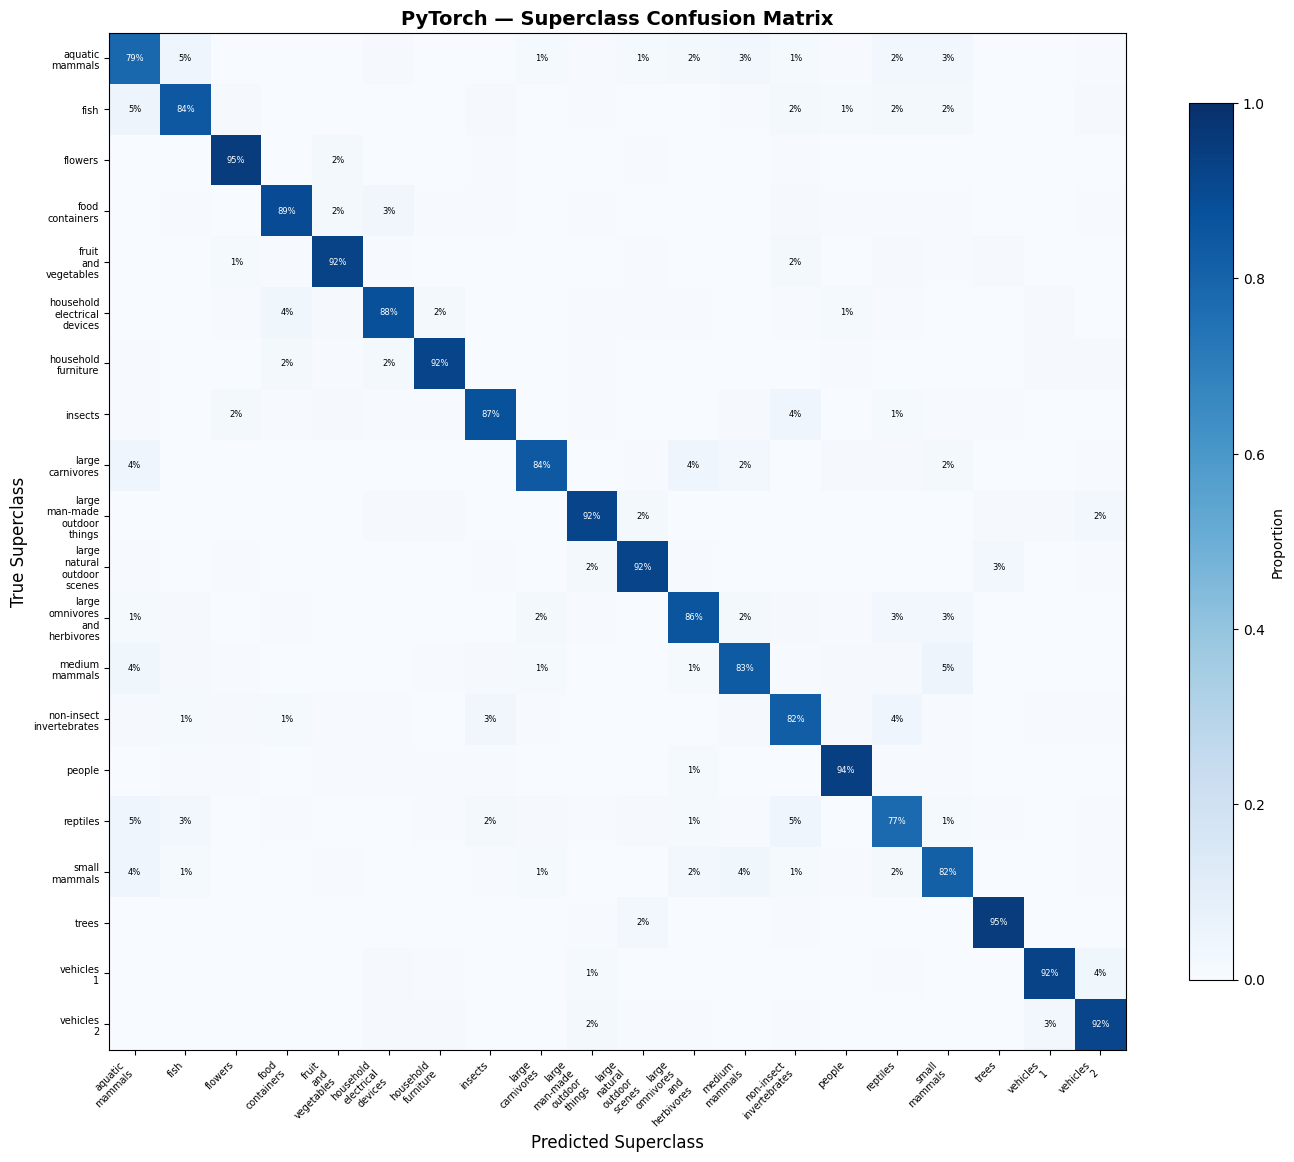


Per-superclass accuracy:
  reptiles                                 77.4%
  aquatic_mammals                          78.8%
  small_mammals                            81.6%
  non-insect_invertebrates                 82.4%
  medium_mammals                           83.4%
  large_carnivores                         84.0%
  fish                                     84.4%
  large_omnivores_and_herbivores           85.6%
  insects                                  87.0%
  household_electrical_devices             87.8%
  food_containers                          89.4%
  vehicles_2                               91.6%
  large_natural_outdoor_scenes             91.8%
  large_man-made_outdoor_things            91.8%
  household_furniture                      92.0%
  fruit_and_vegetables                     92.4%
  vehicles_1                               92.4%
  people                                   94.0%
  flowers                                  95.2%
  trees                                    

In [11]:
# Step 11: Superclass Confusion Analysis

"""
Hierarchical evaluation: how does the model perform at the
superclass level (20 classes)? Which superclasses confuse it?
Validates our EDA predictions about hardest superclasses:
  EDA predicted hardest: people, medium_mammals, non-insect_invertebrates
  EDA predicted easiest: insects, fish, large_natural_outdoor_scenes
"""

print("=" * 60)
print("[11/13] Superclass Confusion Analysis")
print("=" * 60)

# Fine-class accuracy (100 classes) — from best model (Step 10)
fine_acc = float(best_metrics_final['accuracy'])
print(f"Fine-class accuracy (100 classes): {fine_acc:.4f}")

# Superclass accuracy (20 classes) — map predictions to coarse labels
pred_coarse = fine_to_coarse[best_preds_final]
true_coarse = fine_to_coarse[y_test]
superclass_acc = float(np.mean(pred_coarse == true_coarse))
print(f"Superclass accuracy (20 classes): {superclass_acc:.4f}")

# Superclass confusion matrix
plot_superclass_confusion(
    y_true_fine=y_test,
    y_pred_fine=best_preds_final,
    fine_names=FINE_NAMES,
    coarse_names=COARSE_NAMES,
    fine_to_coarse=fine_to_coarse,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/superclass_confusion.png'
)

# Per-fine-class F1 scores
per_class_f1 = []
for c in range(N_CLASSES):
    tp = int(((best_preds_final == c) & (y_test == c)).sum())
    fp = int(((best_preds_final == c) & (y_test != c)).sum())
    fn = int(((best_preds_final != c) & (y_test == c)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    per_class_f1.append((FINE_NAMES[c], f1, COARSE_NAMES[fine_to_coarse[c]]))

per_class_f1.sort(key=lambda x: x[1])

print(f"\n10 Hardest Fine Classes (lowest F1):")
for name, f1, sc in per_class_f1[:10]:
    print(f"  {name:<20} F1={f1:.3f}  (superclass: {sc})")

print(f"\n10 Easiest Fine Classes (highest F1):")
for name, f1, sc in per_class_f1[-10:]:
    print(f"  {name:<20} F1={f1:.3f}  (superclass: {sc})")

# Validate against EDA predictions
print(f"\nEDA predicted hardest superclasses: people, medium_mammals, non-insect_invertebrates")
print(f"EDA predicted easiest superclasses: insects, fish, large_natural_outdoor_scenes")

In [12]:
# Step 12: Performance Benchmarks
"""
Inference speed, model size, GPU memory for the best model
ResNet-20 + CutMix + Label Smoothing + Nesterov (80.0%)

"""
import time

print("=" * 60)
print("[12/13] Performance Benchmarks")
print("=" * 60)

best_model_final.eval()

# Warmup
with torch.no_grad():
    _ = best_model_final(X_test_norm)
torch.cuda.synchronize()

# Timed runs with proper GPU synchronization
n_runs = 10
times = []
for i in range(n_runs):
    torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        _ = best_model_final(X_test_norm)
    torch.cuda.synchronize()  # Wait for GPU to finish before timing
    elapsed = time.perf_counter() - start
    times.append(elapsed)

avg_time = sum(times) / len(times)
n_samples = len(X_test_norm)
per_sample_us = (avg_time / n_samples) * 1e6
throughput = n_samples / avg_time

# Model size
model_size = get_model_size(best_model_final, framework='pytorch')

print(f"\nModel: ResNet-20 + CutMix + Label Smoothing + Nesterov")
print(f"Parameters: {best_params_final:,}")
print(f"Training time: {perf_final['time']:.1f}s ({perf_final['time']/60:.1f} min)")
print(f"GPU memory (training): {perf_final['gpu_memory']:.2f} MB")
print(f"\nInference ({n_runs} runs averaged):")
print(f"  Total time: {avg_time * 1000:.2f} ms ({n_samples:,} samples)")
print(f"  Per sample:  {per_sample_us:.2f} us")
print(f"  Throughput:  {throughput:,.0f} samples/sec")
print(f"\nModel size: {model_size / 1024:.2f} KB ({model_size / (1024**2):.2f} MB)")

[12/13] Performance Benchmarks

Model: ResNet-20 + CutMix + Label Smoothing + Nesterov
Parameters: 4,350,884
Training time: 1973.1s (32.9 min)
GPU memory (training): 8205.11 MB

Inference (10 runs averaged):
  Total time: 421.59 ms (10,000 samples)
  Per sample:  42.16 us
  Throughput:  23,720 samples/sec

Model size: 16995.64 KB (16.60 MB)


In [16]:
# Step 13: Save Results

"""
Save best model results (ResNet-20 + CutMix + Label Smoothing + Nesterov)
Cast all numpy types to native Python for JSON serialization
"""

print("=" * 60)
print("[13/13] Save Results")
print("=" * 60)

test_metrics = {
    'accuracy': float(best_metrics_final['accuracy']),
    'macro_f1': float(best_metrics_final['macro_f1']),
    'log_loss': float(best_metrics_final['log_loss']),
    'brier_score': float(best_metrics_final['brier_score']),
    'ece': float(best_metrics_final['ece'])
}

results = build_results_dict(
    framework=FRAMEWORK,
    model_name=MODEL_NAME,
    test_metrics=test_metrics,
    perf=perf_final,
    inference_stats={
        'total_time': avg_time,
        'per_sample_us': per_sample_us,
        'samples_per_sec': throughput
    },
    model_size=model_size,
    architecture='ResNet-20 (3 stages, 64-128-256)',
    n_params=int(best_params_final),
    epochs=300,
    best_epoch=int(best_history_final['best_epoch']),
    optimizer='SGD Nesterov lr=0.05 wd=5e-4',
    augmentation='CutMix + HFlip + RandomCrop + ColorJitter',
    regularization='Label Smoothing 0.1 + CutMix alpha=1.0',
    lr_schedule='Cosine Annealing (full cycle, no early stop)',
    superclass_accuracy=float(superclass_acc),
    fine_classes=int(N_CLASSES),
    coarse_classes=int(N_SUPERCLASSES),
    dataset='CIFAR-100',
    progression='56.9% -> 61.5% -> 64.2% -> 76.4% -> 77.4% -> 78.8% -> 80.1%'
)

# Save model weights
torch.save(best_model_final.state_dict(), f'{RESULTS_DIR}/resnet20_best.pth')
print(f"\nModel saved: {RESULTS_DIR}/resnet20_best.pth")

save_results(results, f'{RESULTS_DIR}/pt_cnn_results')
add_result('cnn', results)
print_comparison('cnn')

[13/13] Save Results

Model saved: results/resnet20_best.pth
    Results saved to: results/pt_cnn_results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\cnn.json
    Frameworks: 1 recorded

CROSS-FRAMEWORK COMPARISON: CNN
Metric                                                                              PyTorch
-------------------------------------------------------------------------------------------
model                                                                                   CNN
training_time                                                                      32.9 min
inference_time_per_sample_us                                                       42.16 µs
model_size_bytes                                                                   16.60 MB
peak_memory_mb                                                                      1.89 MB
accuracy                                                        